In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.DataFrame({
"Income":[2,3,4,5,7,8,9,10],

"CreditScore":[520,540,560,580,680,700,720,740],

"Approved":[0,0,0,0,1,1,1,1]
})
df

,Income,CreditScore,Approved
0,2,520,0
1,3,540,0
2,4,560,0
3,5,580,0
4,7,680,1
5,8,700,1
6,9,720,1
7,10,740,1


In [3]:
new_income=6
new_credit=650

distances=[]

for i in range(len(df)):
    income=df.loc[i,'Income']
    credit=df.loc[i,'CreditScore']

    distance=np.sqrt(
        (income-new_income)**2+
        (credit-new_credit)**2
    )

    distances.append(distance)

df["Distance"]=distances

df

,Income,CreditScore,Approved,Distance
0,2,520,0,130.061524
1,3,540,0,110.040901
2,4,560,0,90.022219
3,5,580,0,70.007142
4,7,680,1,30.016662
5,8,700,1,50.039984
6,9,720,1,70.064256
7,10,740,1,90.088845


In [4]:
df_sorted=df.sort_values("Distance")

df_sorted

,Income,CreditScore,Approved,Distance
4,7,680,1,30.016662
5,8,700,1,50.039984
3,5,580,0,70.007142
6,9,720,1,70.064256
2,4,560,0,90.022219
7,10,740,1,90.088845
1,3,540,0,110.040901
0,2,520,0,130.061524


In [5]:
k=3

neighbours=df_sorted.head(k)

neighbours

,Income,CreditScore,Approved,Distance
4,7,680,1,30.016662
5,8,700,1,50.039984
3,5,580,0,70.007142


In [6]:
prediction=neighbours["Approved"].mode()[0]
print(prediction)

1


In [7]:
from sklearn.neighbors import KNeighborsClassifier

x=df[['Income',"CreditScore"]]
y=df["Approved"]

In [8]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
new_applicant = [[60000, 750]]

In [10]:
prediction=model.predict(new_applicant)

print(prediction)

[1]


c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [11]:
print(model.predict_proba(new_applicant))

[[0.2 0.8]]


c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.1, random_state=42
)
accuracy = []


max_k = min(20, len(x_train))
k_values = range(1, max_k + 1)


for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    prediction = model.predict(x_test)
    score = accuracy_score(y_test, prediction)
    accuracy.append(score)


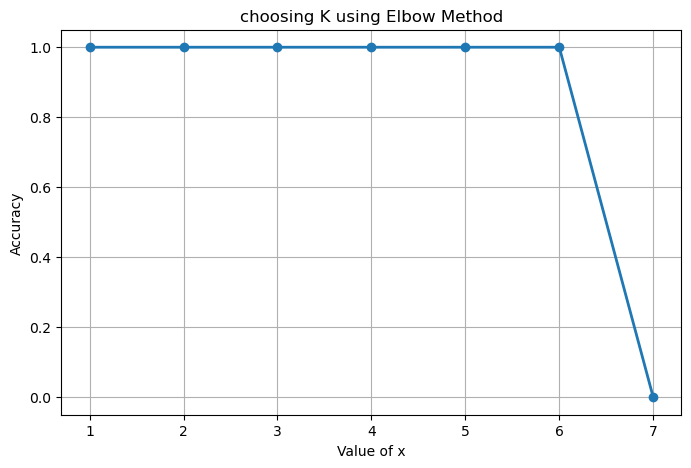

In [18]:
plt.figure(figsize=(8,5))

plt.plot(k_values,accuracy,marker='o',linewidth=2)

plt.xlabel("Value of x")

plt.ylabel("Accuracy")

plt.title("choosing K using Elbow Method")

plt.grid()

plt.show()

In [20]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

cv_accuracy = []


total_samples = len(x)
num_folds = min(6, total_samples)


kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)


max_train_samples = total_samples - (total_samples // num_folds)
max_k = min(20, max_train_samples)

k_values = range(1, max_k + 1)


for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    
    scores = cross_val_score(model, x, y, cv=kf, scoring="accuracy")

    cv_accuracy.append(scores.mean())
for k, acc in zip(k_values, cv_accuracy):
    print(f"K = {k}: Mean CV Accuracy = {acc:.4f}")


K = 1: Mean CV Accuracy = 1.0000
K = 2: Mean CV Accuracy = 1.0000
K = 3: Mean CV Accuracy = 1.0000
K = 4: Mean CV Accuracy = 1.0000
K = 5: Mean CV Accuracy = 1.0000
K = 6: Mean CV Accuracy = 0.5000
K = 7: Mean CV Accuracy = nan


c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "c:\Users\jeeva\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ~~~~~~~~~~~~~~~~~~~~^
        estimator, *args, response_method=response_method, **kwargs
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\jeeva